<a href="https://colab.research.google.com/github/tamartelele/course-qa-rag-lora/blob/main/stage_1_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course Study Assistant — Notebook 1: Data Preparation

## **Tamar Telele** | Applied Language Models | Dr. Barak Or
### Google & Reichman University Tech School

---

> **Notebook 1 of 2** — Building a high-quality, fully course-grounded QA dataset
> from the course materials using the Gemini API, with a rigorous, auditable
> quality-validation protocol.

### Project
**RAG vs. LoRA Fine-Tuning for Course-Specific QA:**
*A Systematic Comparison with Retrieval Method Analysis*

### What this notebook does

| # | Stage | Output |
|---|-------|--------|
| 1 | Extract text from the course PDF slides (`AI_cours_pdfs`) | raw page-level corpus |
| 2 | Apply a 9-step preprocessing pipeline | clean corpus + removal report |
| 3 | Connect to the Gemini API (with retries & rate limiting) | validated client |
| 4 | Generate **1,000 QA pairs** grounded *only* in the course material | raw QA pool |
| 5 | Automatic filtering (heuristics) + **LLM-as-a-Judge** | filtered QA pool |
| 6 | Manual inspection sample (human in the loop) | audit evidence |
| 7 | Dataset statistics & visualizations | figures for the report |
| 8 | Stratified **70 / 15 / 15** split | train / val / test |
| 9 | Persist everything to Google Drive | artifacts for Notebook 2 |



## Cell 1 — Setup, Installation & Global Configuration

Everything that governs this notebook's behaviour lives in **one immutable `Config` object**.
Changing an experiment means changing one line here — never hunting through cells.
We also mount Drive, fix all random seeds, and create the project folder structure.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 1 — Setup, Installation & Global Configuration
#  Author: Tamar Telele
# ═══════════════════════════════════════════════════════════════════════════════

# --- Dependencies (quiet install keeps the notebook output clean and readable) ---
!pip install -q pymupdf google-genai pandas tqdm matplotlib seaborn

# --- Standard library ---
import json
import os
import random
import re
import hashlib
import time
import unicodedata
from dataclasses import dataclass, asdict, field
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# --- Third party ---
import fitz                      # PyMuPDF — fastest reliable PDF text extractor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
from google.genai import types
from tqdm.auto import tqdm

# --- Google Colab integration ---
from google.colab import drive, userdata

# ───────────────────────────────────────────────────────────────────────────────
#  Global configuration — the single source of truth for the whole notebook
# ───────────────────────────────────────────────────────────────────────────────
@dataclass(frozen=True)
class Config:
    """Immutable experiment configuration (frozen = cannot be mutated by accident)."""

    # -- Storage --------------------------------------------------------------
    DRIVE_ROOT: Path = Path("/content/drive/MyDrive")
    PDF_FOLDER: str = "AI_cours_pdfs"            # where the course PDFs live
    PROJECT_FOLDER: str = "course_study_assistant"

    # -- Generation -----------------------------------------------------------
    GEMINI_MODEL: str = "gemini-3.5-flash-lite"
    TARGET_QA_PAIRS: int = 1000
    QA_PER_CHUNK: int = 8                        # asked per chunk; we over-generate on purpose
    GEN_CHUNK_CHARS: int = 1500                  # context window given to the generator
    GEN_CHUNK_OVERLAP: int = 200
    CHECKPOINT_EVERY: int = 100                  # crash-safety for long API loops
    MAX_RETRIES: int = 4
    REQUEST_SLEEP: float = 4.0                   # polite pacing for the free tier

    # -- Quality gates --------------------------------------------------------
    MIN_QUESTION_CHARS: int = 15
    MIN_ANSWER_CHARS: int = 10
    MAX_ANSWER_CHARS: int = 400
    NEAR_DUP_THRESHOLD: float = 0.85             # Jaccard similarity on token shingles
    JUDGE_MIN_SCORE: float = 4.0                 # 1–5 scale, average across 4 criteria
    MANUAL_SAMPLE_SIZE: int = 10                 # shown inline; full audit sheet = 10% of data

    # -- Split ----------------------------------------------------------------
    TRAIN_RATIO: float = 0.70
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    # -- Reproducibility ------------------------------------------------------
    SEED: int = 42

    # -- Derived paths --------------------------------------------------------
    @property
    def pdf_dir(self) -> Path:         return self.DRIVE_ROOT / self.PDF_FOLDER
    @property
    def project_dir(self) -> Path:     return self.DRIVE_ROOT / self.PROJECT_FOLDER
    @property
    def data_dir(self) -> Path:        return self.project_dir / "data"
    @property
    def figures_dir(self) -> Path:     return self.project_dir / "figures"
    @property
    def checkpoints_dir(self) -> Path: return self.project_dir / "checkpoints"
    @property
    def reports_dir(self) -> Path:     return self.project_dir / "reports"

    def output_dirs(self) -> List[Path]:
        return [self.project_dir, self.data_dir, self.figures_dir,
                self.checkpoints_dir, self.reports_dir]


CFG = Config()

# ───────────────────────────────────────────────────────────────────────────────
#  Reproducibility — one seed to rule them all
# ───────────────────────────────────────────────────────────────────────────────
def set_global_seed(seed: int) -> None:
    """Fix every source of randomness we touch in this notebook."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_global_seed(CFG.SEED)

# ───────────────────────────────────────────────────────────────────────────────
#  Plot style — one consistent, report-ready look for every figure
# ───────────────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 11,
})
PALETTE = ["#2E86AB", "#F6511D", "#7FB800", "#8E44AD", "#FFB400", "#00A6ED"]


def save_figure(fig, name: str) -> None:
    """Persist a figure to Drive so it can be dropped straight into the report."""
    path = CFG.figures_dir / f"{name}.png"
    fig.savefig(path)
    print(f"   figure saved: {path.name}")


# ───────────────────────────────────────────────────────────────────────────────
#  Mount Drive and prepare the project tree
# ───────────────────────────────────────────────────────────────────────────────
drive.mount("/content/drive", force_remount=False)

for directory in CFG.output_dirs():
    directory.mkdir(parents=True, exist_ok=True)

assert CFG.pdf_dir.exists(), (
    f"PDF folder not found: {CFG.pdf_dir}\n"
    f"Create it in your Drive and upload the course slides there."
)

# ───────────────────────────────────────────────────────────────────────────────
#  Print the effective configuration — an experiment you cannot read is not reproducible
# ───────────────────────────────────────────────────────────────────────────────
print("=" * 79)
print("  COURSE STUDY ASSISTANT  |  NOTEBOOK 1 — DATA PREPARATION")
print("  Tamar Telele  |  Applied Language Models  |  Dr. Barak Or")
print("=" * 79)
print(f"  Run started        : {datetime.now():%Y-%m-%d %H:%M:%S}")
print(f"  PDF source folder  : {CFG.pdf_dir}")
print(f"  Project folder     : {CFG.project_dir}")
print(f"  Generator model    : {CFG.GEMINI_MODEL}")
print(f"  Target QA pairs    : {CFG.TARGET_QA_PAIRS:,}")
print(f"  Split (train/val/test): "
      f"{CFG.TRAIN_RATIO:.0%} / {CFG.VAL_RATIO:.0%} / {CFG.TEST_RATIO:.0%}")
print(f"  Global seed        : {CFG.SEED}")
print("=" * 79)
print("Environment ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  COURSE STUDY ASSISTANT  |  NOTEBOOK 1 — DATA PREPARATION
  Tamar Telele  |  Applied Language Models  |  Dr. Barak Or
  Run started        : 2026-08-30 13:55:11
  PDF source folder  : /content/drive/MyDrive/AI_cours_pdfs
  Project folder     : /content/drive/MyDrive/course_study_assistant
  Generator model    : gemini-3.5-flash-lite
  Target QA pairs    : 1,000
  Split (train/val/test): 70% / 15% / 15%
  Global seed        : 42
Environment ready.


## Cell 2 — Step 1: Extract Text from PDFs
Extracts text page by page from `MyDrive/AI_cours_pdfs` for full traceability (file + page).
In lecture slides, page ≈ one idea — a natural extraction unit.
Per-file statistics are captured to detect silent extraction failures.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 2 — Step 1: PDF Text Extraction
# ═══════════════════════════════════════════════════════════════════════════════

def extract_text_from_pdf(pdf_path: Path) -> List[Dict]:
    """Extract text from a single PDF, one record per page.

    Args:
        pdf_path: Path to the PDF file.

    Returns:
        A list of page records: {source, page, text, n_chars}.
        Pages that contain no extractable text are kept with an empty string so
        that we can report them — silence is the enemy of data quality.
    """
    pages: List[Dict] = []
    with fitz.open(pdf_path) as doc:
        for page_number, page in enumerate(doc, start=1):
            text = page.get_text("text") or ""
            pages.append({
                "source": pdf_path.name,
                "page": page_number,
                "text": text,
                "n_chars": len(text.strip()),
            })
    return pages

def load_corpus(pdf_dir: Path) -> pd.DataFrame:
    """Load every PDF in a folder into a tidy page-level DataFrame."""
    pdf_files = sorted(pdf_dir.glob("*.pdf"))
    if not pdf_files:
        raise FileNotFoundError(f"No PDF files found in {pdf_dir}")

    records: List[Dict] = []
    for pdf_path in tqdm(pdf_files, desc="Reading PDFs"):
        try:
            records.extend(extract_text_from_pdf(pdf_path))
        except Exception as exc:                        # never let one bad file stop the run
            print(f"   could not read {pdf_path.name}: {exc}")
    return pd.DataFrame.from_records(records)


# --- Run the extraction --------------------------------------------------------
raw_pages = load_corpus(CFG.pdf_dir)

# --- Per-file extraction report -----------------------------------------------
file_stats = (
    raw_pages
    .groupby("source")
    .agg(pages=("page", "count"),
         characters=("n_chars", "sum"),
         empty_pages=("n_chars", lambda s: int((s == 0).sum())),
         avg_chars_per_page=("n_chars", "mean"))
    .round(0)
    .astype({"avg_chars_per_page": int})
    .sort_values("characters", ascending=False)
)

print("=" * 79)
print("  PDF EXTRACTION REPORT")
print("=" * 79)
display(file_stats)

total_chars = int(raw_pages["n_chars"].sum())
empty_ratio = (raw_pages["n_chars"] == 0).mean()

print(f"  Files processed     : {raw_pages['source'].nunique()}")
print(f"  Pages extracted     : {len(raw_pages):,}")
print(f"  Characters extracted: {total_chars:,}")
print(f"  Empty pages         : {empty_ratio:.1%}")

# A high ratio of empty pages almost always means image-only (scanned) slides,
if empty_ratio > 0.30:
    print("  WARNING: many pages have no extractable text — these slides may be images (OCR needed).")
else:
    print("  Extraction quality looks healthy.")
print("=" * 79)

Reading PDFs:   0%|          | 0/9 [00:00<?, ?it/s]

  PDF EXTRACTION REPORT


,pages,characters,empty_pages,avg_chars_per_page
source,,,,
Classical ML Models (1).pdf,112,52742,0,471
Computer Vision and CNNs - Part 2 120726 (2).pdf,87,35801,0,412
Introduction 230626.pdf,98,35301,0,360
NLP using Transformers Part 1.pdf,81,32597,0,402
Deep Learning Principles.pdf,88,31958,0,363
Computer Vision and CNNs - Part 1 090726 (1).pdf,61,25973,0,426
Deep Reinforcement Learning.pdf,62,23802,0,384
GANs 20082026.pdf,49,22706,0,463
NLP using Transformers - Advanced Topics (1).pdf,51,16872,0,331


  Files processed     : 9
  Pages extracted     : 689
  Characters extracted: 277,752
  Empty pages         : 0.0%
  Extraction quality looks healthy.


## Cell 3 — Step 2: Preprocessing Pipeline (9 steps)


| # | Step | Why |
|---|------|-----|
| 1 | Lowercase | consistency between tokens |
| 2 | Strip whitespace (`\n`, `\t`, multiple spaces) | basic normalisation |
| 3 | Remove empty lines | less noise |
| 4 | Remove short lines (< 10 chars) | titles / page numbers carry no content |
| 5 | Remove special characters (`@ # * • ▪ …`) | slide decoration symbols |
| 6 | Remove slide / page numbers | non-semantic numbers |
| 7 | Remove URLs | not part of the course content |
| 8 | Remove duplicate sentences | prevents training bias from repeated slides |
| 9 | Minimal punctuation cleaning | **`.` and `,` are preserved — they are critical for chunking** |


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 3 — Step 2: Preprocessing Pipeline (9 ordered steps)
# ═══════════════════════════════════════════════════════════════════════════════

# --- Compiled patterns (compiled once, reused thousands of times) --------------
URL_PATTERN          = re.compile(r"(https?://\S+|www\.\S+|\S+@\S+\.\S+)")
SPECIAL_CHARS        = re.compile(r"[•▪◦●○■□▶►★☆♦♣♠✓✔✦→⇒«»~^_|\\<>{}\[\]#*@]")
SLIDE_NUMBER_PATTERN = re.compile(
    r"^\s*(slide|page|עמוד|שקף)?\s*\d{1,3}\s*(/|of|\|)?\s*\d{0,3}\s*$", re.IGNORECASE)
MULTI_SPACE          = re.compile(r"[ \t]{2,}")
MULTI_PUNCT          = re.compile(r"([.,!?])\1{1,}")
SENTENCE_SPLIT       = re.compile(r"(?<=[.!?])\s+")


@dataclass
class CleaningReport:
    """Bookkeeping for the pipeline — how much did each step actually remove?"""
    lines_in: int = 0
    lines_after_empty: int = 0
    lines_after_short: int = 0
    lines_after_slide_numbers: int = 0
    sentences_in: int = 0
    sentences_after_dedup: int = 0
    chars_in: int = 0
    chars_out: int = 0

    def as_dataframe(self) -> pd.DataFrame:
        rows = [
            ("Lines — raw",                    self.lines_in),
            ("Lines — after empty removal",    self.lines_after_empty),
            ("Lines — after short removal",    self.lines_after_short),
            ("Lines — after number removal",   self.lines_after_slide_numbers),
            ("Sentences — before dedup",       self.sentences_in),
            ("Sentences — after dedup",        self.sentences_after_dedup),
            ("Characters — before",            self.chars_in),
            ("Characters — after",             self.chars_out),
        ]
        df = pd.DataFrame(rows, columns=["stage", "count"])
        df["kept_%"] = [
            100.0,
            100 * self.lines_after_empty / max(self.lines_in, 1),
            100 * self.lines_after_short / max(self.lines_in, 1),
            100 * self.lines_after_slide_numbers / max(self.lines_in, 1),
            100.0,
            100 * self.sentences_after_dedup / max(self.sentences_in, 1),
            100.0,
            100 * self.chars_out / max(self.chars_in, 1),
        ]
        return df.round(1)


class PreprocessingPipeline:
    """
    The pipeline is stateful only for reporting
    """

    def __init__(self, min_line_chars: int = 10):
        self.min_line_chars = min_line_chars
        self.report = CleaningReport()
        self._seen_sentences: set = set()      # global dedup across the whole corpus

    # ---- Step 1 --------------------------------------------------------------
    @staticmethod
    def step1_lowercase(text: str) -> str:
        """Lowercase everything for token consistency."""
        return text.lower()

    # ---- Step 2 --------------------------------------------------------------
    @staticmethod
    def step2_strip_whitespace(text: str) -> str:
        """Normalise unicode, tabs, non-breaking spaces and repeated spaces."""
        text = unicodedata.normalize("NFKC", text)
        text = text.replace("\xa0", " ").replace("\t", " ").replace("\r", "\n")
        return MULTI_SPACE.sub(" ", text)

    # ---- Step 3 --------------------------------------------------------------
    def step3_remove_empty_lines(self, lines: List[str]) -> List[str]:
        kept = [ln.strip() for ln in lines if ln.strip()]
        self.report.lines_after_empty += len(kept)
        return kept

    # ---- Step 4 --------------------------------------------------------------
    def step4_remove_short_lines(self, lines: List[str]) -> List[str]:
        kept = [ln for ln in lines if len(ln) >= self.min_line_chars]
        self.report.lines_after_short += len(kept)
        return kept

    # ---- Step 5 --------------------------------------------------------------
    @staticmethod
    def step5_remove_special_chars(text: str) -> str:
        """Drop slide decoration symbols. Sentence punctuation is untouched."""
        return SPECIAL_CHARS.sub(" ", text)

    # ---- Step 6 --------------------------------------------------------------
    def step6_remove_slide_numbers(self, lines: List[str]) -> List[str]:
        kept = [ln for ln in lines if not SLIDE_NUMBER_PATTERN.match(ln)]
        self.report.lines_after_slide_numbers += len(kept)
        return kept

    # ---- Step 7 --------------------------------------------------------------
    @staticmethod
    def step7_remove_urls(text: str) -> str:
        return URL_PATTERN.sub(" ", text)

    # ---- Step 8 --------------------------------------------------------------
    def step8_remove_duplicate_sentences(self, text: str) -> str:
        """Corpus-level sentence dedup — repeated slide footers appear dozens of times."""
        sentences = [s.strip() for s in SENTENCE_SPLIT.split(text) if s.strip()]
        self.report.sentences_in += len(sentences)
        unique = []
        for sentence in sentences:
            key = re.sub(r"\W+", "", sentence)       # signature ignoring punctuation/spacing
            if key and key not in self._seen_sentences:
                self._seen_sentences.add(key)
                unique.append(sentence)
        self.report.sentences_after_dedup += len(unique)
        return " ".join(unique)

    # ---- Step 9 --------------------------------------------------------------
    @staticmethod
    def step9_clean_punctuation(text: str) -> str:
        """Minimal punctuation repair: collapse '....' -> '.', fix spacing.

        We intentionally KEEP '.' and ',' — they are the chunk separators used by the
        RecursiveCharacterTextSplitter in Notebook 2.
        """
        text = MULTI_PUNCT.sub(r"\1", text)
        text = re.sub(r"\s+([.,!?])", r"\1", text)
        text = re.sub(r"([.,!?])(?=[^\s])", r"\1 ", text)
        return MULTI_SPACE.sub(" ", text).strip()

    # ---- Full pipeline -------------------------------------------------------
    def __call__(self, text: str) -> str:
        self.report.chars_in += len(text)

        text = self.step1_lowercase(text)
        text = self.step2_strip_whitespace(text)

        lines = text.split("\n")
        self.report.lines_in += len(lines)
        lines = self.step3_remove_empty_lines(lines)
        lines = self.step4_remove_short_lines(lines)
        lines = self.step6_remove_slide_numbers(lines)

        text = "\n".join(lines)
        text = self.step5_remove_special_chars(text)
        text = self.step7_remove_urls(text)
        text = self.step8_remove_duplicate_sentences(text)
        text = self.step9_clean_punctuation(text)

        self.report.chars_out += len(text)
        return text


# --- Before / after demonstration on a real page -------------------------------
demo_page = raw_pages.loc[raw_pages["n_chars"].idxmax(), "text"]
demo_pipeline = PreprocessingPipeline()

print("=" * 79)
print("  BEFORE / AFTER — a single real slide page")
print("=" * 79)
print("BEFORE:\n" + demo_page[:400].replace("\n", " | "))
print("\nAFTER:\n" + demo_pipeline(demo_page)[:400])
print("=" * 79)

# --- Run the pipeline over the whole corpus ------------------------------------
pipeline = PreprocessingPipeline(min_line_chars=10)
raw_pages["clean_text"] = [pipeline(t) for t in tqdm(raw_pages["text"], desc="Cleaning")]

clean_pages = raw_pages[raw_pages["clean_text"].str.len() > 50].reset_index(drop=True)

print("\n  CLEANING REPORT")
display(pipeline.report.as_dataframe())
print(f"  Pages kept          : {len(clean_pages):,} / {len(raw_pages):,}")
print(f"  Characters retained : {pipeline.report.chars_out:,} "
      f"({pipeline.report.chars_out / max(pipeline.report.chars_in, 1):.1%} of raw)")
print("  Note: the reduction is expected — it is exactly the boilerplate, decoration")
print("        and duplicated slide furniture that we do NOT want the model to learn.")

  BEFORE / AFTER — a single real slide page
BEFORE:
Artificial Intelligence and Deep Learning Development | Dynamic Programming | Bellman equation – code example | ( ) | ( | ) | ( | ) | ( ) | ' | max | '| , | , , ' | ' | a | s | V s | P s | s a | R s a s | V s |  | = | + |  |  |  |  |  | The goal is to find the optimal value function V(s) for each state s, which in turn helps in determining  | the optimal policy. | import numpy as np | V = np.zeros(n_states) # Initialize value function | # Value iteration p

AFTER:
artificial intelligence and deep learning development
dynamic programming
bellman equation – code example
the goal is to find the optimal value function v(s) for each state s, which in turn helps in determining
the optimal policy. import numpy as np
v = np. zeros(n states) initialize value function
 value iteration parameters
theta = 1e-6
gamma = 0. 99
max iterations = 1000
for i in range(max iter


Cleaning:   0%|          | 0/689 [00:00<?, ?it/s]


  CLEANING REPORT


,stage,count,kept_%
0,Lines — raw,11020,100.0
1,Lines — after empty removal,10302,93.5
2,Lines — after short removal,5840,53.0
3,Lines — after number removal,5840,53.0
4,Sentences — before dedup,2679,100.0
5,Sentences — after dedup,2381,88.9
6,Characters — before,278503,100.0
7,Characters — after,245494,88.1


  Pages kept          : 626 / 689
  Characters retained : 245,494 (88.1% of raw)
  Note: the reduction is expected — it is exactly the boilerplate, decoration
        and duplicated slide furniture that we do NOT want the model to learn.


## Cell 4 — Step 3: Gemini API Setup & Connection Test

The API key is read from **Colab Secrets**.

wraps the client in a thin `GeminiClient` class that adds what production code always needs:
**exponential-backoff retries, rate-limit pacing, and strict JSON parsing.**

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 4 — Step 3: Gemini API Setup + Connection Test
# ═══════════════════════════════════════════════════════════════════════════════

def load_api_key() -> str:
    """Read the API key from Colab Secrets, falling back to a masked prompt."""
    try:
        key = userdata.get("GOOGLE_API_KEY")
        if key:
            print("API key loaded from Colab Secrets.")
            return key
    except Exception:
        pass
    from getpass import getpass
    print("Secret 'GOOGLE_API_KEY' not found — falling back to manual entry.")
    return getpass("Enter your Google AI Studio API key: ")


class GeminiClient:
    """A small, dependable wrapper around the Gemini API.

    Adds the three things:
      1. exponential-backoff retries on transient failures / rate limits
      2. polite pacing between requests (free tier friendly)
      3. tolerant JSON extraction, because LLMs like to wrap JSON in markdown fences
    """

    JSON_FENCE = re.compile(r"```(?:json)?\s*(.*?)\s*```", re.DOTALL)

    def __init__(self, api_key: str, model_name: str,
                 max_retries: int = 4, sleep_between: float = 1.0):
        self.client = genai.Client(api_key=api_key)
        self.model_name = model_name
        self.max_retries = max_retries
        self.sleep_between = sleep_between
        self.n_calls = 0
        self.n_failures = 0

    def generate(self, prompt: str, temperature: float = 0.4,
             max_output_tokens: int = 2048) -> Optional[str]:
        """Single call with retries. Returns None only if every attempt failed."""
        config = types.GenerateContentConfig(
          temperature=temperature,
          max_output_tokens=max_output_tokens,
        )
        for attempt in range(1, self.max_retries + 1):
            try:
              self.n_calls += 1
              response = self.client.models.generate_content(
                  model=self.model_name,
                  contents=prompt,
                  config=config,
              )
              # Aggregate all parts to avoid truncation in multi-part responses
              full_text = "".join(part.text for part in response.candidates[0].content.parts)
              time.sleep(self.sleep_between)
              return full_text
            except Exception as exc:
              wait = min(2 ** attempt, 30)          # 2, 4, 8, 16 … seconds
              if attempt == self.max_retries:
                  self.n_failures += 1
                  print(f"   request failed permanently: {type(exc).__name__}")
                  return None
              time.sleep(wait)
        return None

    def generate_json(self, prompt: str, **kwargs):
        """Call the model and parse the reply as JSON, tolerating markdown fences."""
        raw = self.generate(prompt, **kwargs)
        if raw is None:
            return None
        candidate = raw.strip()
        fenced = self.JSON_FENCE.search(candidate)
        if fenced:
            candidate = fenced.group(1)
        try:
            return json.loads(candidate)
        except json.JSONDecodeError:
            # Last resort: salvage the outermost JSON array/object in the string.
            match = re.search(r"[\[{].*[\]}]", candidate, re.DOTALL)
            if match:
                try:
                    return json.loads(match.group(0))
                except json.JSONDecodeError:
                    return None
            return None

    def stats(self) -> Dict:
        return {"calls": self.n_calls, "permanent_failures": self.n_failures}


# --- Instantiate and verify the connection before spending an hour on generation ---
gemini = GeminiClient(
    api_key=load_api_key(),
    model_name=CFG.GEMINI_MODEL,
    max_retries=CFG.MAX_RETRIES,
    sleep_between=CFG.REQUEST_SLEEP,
)

test_reply = gemini.generate_json(
    'Reply with exactly this JSON and nothing else: {"status": "ok"}',
    temperature=0.0, max_output_tokens=256,
)

print("=" * 79)
if test_reply and test_reply.get("status") == "ok":
    print(f"  CONNECTION TEST PASSED — model '{CFG.GEMINI_MODEL}' is responding correctly.")
else:
    raise RuntimeError("Connection test failed. Check the API key, quota and model name.")
print("=" * 79)

API key loaded from Colab Secrets.
  CONNECTION TEST PASSED — model 'gemini-3.5-flash-lite' is responding correctly.


## Cell 5 — Step 4: Generate QA Pairs with Gemini

### Prompt-engineering decisions (this is where dataset quality is actually decided)

| Decision | Rationale |
|---|---|
| **Strict grounding instruction** | The model must answer *only* from the given chunk. This is what makes hallucination measurable later. |
| **`response_mime_type="application/json"`** | Structured output beats regex-scraping prose. Fewer parsing failures, fewer silent losses. |
| **Explicit question-type mix** (factual / conceptual / comparative) | A dataset of only "what is X?" cannot distinguish RAG from LoRA. Diversity is what makes the comparison in Notebook 2 informative. |
| **Self-declared `topic` per pair** | Enables a *stratified* split and the topic-coloured t-SNE plot in Notebook 2. |
| **Over-generate then filter** | We request ~30% more than the target so that the quality gates can be strict without missing the 1,000-pair goal. |
| **Checkpoint every 100 pairs** | A dropped connection after 45 minutes must never cost 45 minutes. |
| **temperature = 0.4** | Enough variety to avoid template-y questions, low enough to stay faithful to the source. |

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 5 — Step 4: QA Generation with Gemini
# ═══════════════════════════════════════════════════════════════════════════════

def build_generation_chunks(pages: pd.DataFrame,
                            chunk_chars: int,
                            overlap: int) -> List[Dict]:
    """Group cleaned pages into overlapping context windows for the generator.

    Chunks respect document boundaries (we never mix two different PDFs into one
    context) and keep provenance so every QA pair remains traceable to file + pages.
    """
    chunks: List[Dict] = []
    for source, group in pages.groupby("source", sort=False):
        group = group.sort_values("page")
        buffer, buffer_pages = "", []
        for _, row in group.iterrows():
            buffer += " " + row["clean_text"]
            buffer_pages.append(int(row["page"]))
            if len(buffer) >= chunk_chars:
                chunks.append({
                    "chunk_id": f"{source}::p{buffer_pages[0]}-{buffer_pages[-1]}",
                    "source": source,
                    "pages": [buffer_pages[0], buffer_pages[-1]],
                    "text": buffer.strip(),
                })
                buffer = buffer[-overlap:]           # overlap preserves cross-page context
                buffer_pages = buffer_pages[-1:]
        if len(buffer.strip()) > 200:                # keep a meaningful tail
            chunks.append({
                "chunk_id": f"{source}::p{buffer_pages[0]}-{buffer_pages[-1]}",
                "source": source,
                "pages": [buffer_pages[0], buffer_pages[-1]],
                "text": buffer.strip(),
            })
    return chunks


QA_GENERATION_PROMPT = """You are an expert teaching assistant for a university course on
Applied Language Models. You are creating an exam-quality question-answering dataset.

Below is an excerpt from the official course slides.

<course_material>
{chunk}
</course_material>

Write exactly {n} question-answer pairs based STRICTLY on the material above.

HARD RULES:
1. Every answer must be fully supported by the excerpt. Never use outside knowledge.
2. If the excerpt does not contain enough substance for {n} good pairs, return fewer.
3. Questions must be self-contained: never write "according to the slide" or "in the text above".
4. Answers must be concise and factual: 1-3 sentences, no filler, no bullet points.
5. Vary the question types across the set:
   - "factual"     : a definition, a value, a name, a formula
   - "conceptual"  : why something works, what a mechanism does
   - "comparative" : how two ideas or methods differ
6. Assign each pair a short topic label (1-3 words) taken from the material,
   for example: "rag", "lora", "tokenization", "evaluation metrics", "embeddings".

Return ONLY a JSON array with this exact schema:
[
  {{"question": "...", "answer": "...", "type": "factual", "topic": "..."}}
]"""


def generate_qa_dataset(client: GeminiClient,
                        chunks: List[Dict],
                        target_pairs: int,
                        pairs_per_chunk: int,
                        checkpoint_every: int,
                        checkpoint_path: Path) -> List[Dict]:
    """Iterate over chunks and generate QA pairs, checkpointing as we go."""
    collected: List[Dict] = []

    # Resume support: if a checkpoint exists we continue instead of starting over.
    if checkpoint_path.exists():
        collected = json.loads(checkpoint_path.read_text(encoding="utf-8"))
        print(f"Resuming from checkpoint with {len(collected)} existing pairs.")

    processed_chunks = {item["chunk_id"] for item in collected}
    pending = [c for c in chunks if c["chunk_id"] not in processed_chunks]

    progress = tqdm(pending, desc="Generating QA pairs")
    for chunk in progress:
        if len(collected) >= target_pairs * 1.3:      # deliberate over-generation
            break

        prompt = QA_GENERATION_PROMPT.format(chunk=chunk["text"], n=pairs_per_chunk)
        payload = client.generate_json(prompt, temperature=0.4, max_output_tokens=2048)

        if not isinstance(payload, list):
            continue

        for item in payload:
            if not isinstance(item, dict):
                continue
            question, answer = item.get("question"), item.get("answer")
            if not question or not answer:
                continue
            collected.append({
                "id": f"qa_{len(collected):05d}",
                "question": str(question).strip(),
                "answer": str(answer).strip(),
                "type": str(item.get("type", "factual")).strip().lower(),
                "topic": str(item.get("topic", "general")).strip().lower(),
                "source": chunk["source"],
                "pages": chunk["pages"],
                "chunk_id": chunk["chunk_id"],
                "context": chunk["text"][:1500],      # kept for the LLM judge & error analysis
            })

        progress.set_postfix(pairs=len(collected))

        if len(collected) % checkpoint_every < pairs_per_chunk:
            checkpoint_path.write_text(json.dumps(collected, ensure_ascii=False, indent=2),
                                       encoding="utf-8")

    checkpoint_path.write_text(json.dumps(collected, ensure_ascii=False, indent=2),
                               encoding="utf-8")
    return collected


# --- Build the generation contexts ---------------------------------------------
generation_chunks = build_generation_chunks(
    clean_pages, CFG.GEN_CHUNK_CHARS, CFG.GEN_CHUNK_OVERLAP
)
print(f"Prepared {len(generation_chunks)} generation contexts "
      f"(~{CFG.GEN_CHUNK_CHARS} characters each) from {clean_pages['source'].nunique()} documents.")
# --- Generate ------------------------------------------------------------------
raw_qa_pairs = generate_qa_dataset(
    client=gemini,
    chunks=generation_chunks,
    target_pairs=CFG.TARGET_QA_PAIRS,
    pairs_per_chunk=CFG.QA_PER_CHUNK,
    checkpoint_every=CFG.CHECKPOINT_EVERY,
    checkpoint_path=CFG.checkpoints_dir / "qa_raw_checkpoint.json",
)


print("=" * 79)
print(f"  RAW QA PAIRS GENERATED : {len(raw_qa_pairs):,}")
print(f"  API calls              : {gemini.stats()['calls']}")
print(f"  Permanent failures     : {gemini.stats()['permanent_failures']}")
print(f"  Distinct topics        : {len({p['topic'] for p in raw_qa_pairs})}")
print("=" * 79)


Prepared 161 generation contexts (~1500 characters each) from 9 documents.
  RAW QA PAIRS GENERATED : 1,285
  API calls              : 1
  Permanent failures     : 0
  Distinct topics        : 626


## Cell 6a — Step 5a: Automatic Heuristic Filtering

The cheap gate runs first. Deterministic rules catch the failure modes we can define
precisely, so the expensive LLM judge only sees candidates that are already plausible:

1. **Length bounds** — questions < 15 chars or answers < 10 / > 400 chars.
2. **Degenerate answers** — "yes", "no", "n/a", "the text does not say".
3. **Leakage phrases** — "according to the slide", "in the text above" (non-self-contained).
4. **Exact duplicates** — identical normalised question strings.
5. **Near duplicates** — Jaccard similarity ≥ 0.85 on word shingles, which catches
   "what is lora?" vs "what is lora fine-tuning?" style clones that exact matching misses.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 6a — Step 5a: Automatic Heuristic Filtering
# ═══════════════════════════════════════════════════════════════════════════════

DEGENERATE_ANSWERS = {"yes", "no", "n/a", "na", "none", "unknown", "not specified"}
LEAKAGE_PHRASES = ("according to the slide", "in the text above", "as shown above",
                   "the excerpt", "the passage", "based on the material above",
                   "the document states", "the slide says")


def normalise(text: str) -> str:
    """Canonical form used for duplicate detection only."""
    return re.sub(r"\W+", " ", text.lower()).strip()


def shingles(text: str, size: int = 3) -> set:
    """Word-level n-gram shingles used for near-duplicate detection."""
    words = normalise(text).split()
    if len(words) < size:
        return {" ".join(words)}
    return {" ".join(words[i:i + size]) for i in range(len(words) - size + 1)}


def jaccard(a: set, b: set) -> float:
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


def heuristic_filter(pairs: List[Dict], cfg: Config) -> Tuple[List[Dict], pd.DataFrame]:
    """Apply the deterministic quality gates and return survivors + a rejection report."""
    rejections = {"too_short": 0, "answer_too_long": 0, "degenerate_answer": 0,
                  "not_self_contained": 0, "exact_duplicate": 0, "near_duplicate": 0}

    kept: List[Dict] = []
    seen_exact: set = set()
    seen_shingles: List[set] = []

    for pair in pairs:
        question, answer = pair["question"], pair["answer"]

        if len(question) < cfg.MIN_QUESTION_CHARS or len(answer) < cfg.MIN_ANSWER_CHARS:
            rejections["too_short"] += 1
            continue
        if len(answer) > cfg.MAX_ANSWER_CHARS:
            rejections["answer_too_long"] += 1
            continue
        if normalise(answer) in DEGENERATE_ANSWERS:
            rejections["degenerate_answer"] += 1
            continue
        if any(phrase in question.lower() or phrase in answer.lower()
               for phrase in LEAKAGE_PHRASES):
            rejections["not_self_contained"] += 1
            continue

        key = normalise(question)
        if key in seen_exact:
            rejections["exact_duplicate"] += 1
            continue

        candidate_shingles = shingles(question)
        if any(jaccard(candidate_shingles, existing) >= cfg.NEAR_DUP_THRESHOLD
               for existing in seen_shingles):
            rejections["near_duplicate"] += 1
            continue

        seen_exact.add(key)
        seen_shingles.append(candidate_shingles)
        kept.append(pair)

    report = (pd.DataFrame(rejections.items(), columns=["reason", "removed"])
              .sort_values("removed", ascending=False)
              .reset_index(drop=True))
    return kept, report


filtered_pairs, rejection_report = heuristic_filter(raw_qa_pairs, CFG)

print("=" * 79)
print("  HEURISTIC FILTERING REPORT")
print("=" * 79)
display(rejection_report)
print(f"  In  : {len(raw_qa_pairs):,} pairs")
print(f"  Out : {len(filtered_pairs):,} pairs "
      f"({len(filtered_pairs) / max(len(raw_qa_pairs), 1):.1%} survived)")
print("=" * 79)

  HEURISTIC FILTERING REPORT


,reason,removed
0,too_short,3
1,exact_duplicate,2
2,not_self_contained,1
3,answer_too_long,0
4,degenerate_answer,0
5,near_duplicate,0


  In  : 1,285 pairs
  Out : 1,279 pairs (99.5% survived)


## Cell 6b — Step 5b: LLM-as-a-Judge (Gemini grades its own output)

A generator grading itself sounds circular, so we make the setup **asymmetric** on purpose:

- The judge sees the **source context**, the question and the answer, and is asked a
  *verification* question ("is this answer supported by this text?"), which is a strictly
  easier and better-calibrated task than generation.
- The judge scores **four independent criteria** on a 1–5 scale — `groundedness`,
  `correctness`, `clarity`, `self_containment` — rather than a single vague "quality" score.
- Judging runs at **temperature 0.0** for determinism and reproducibility.
- Pairs are accepted only if the **mean score ≥ 4.0** *and* `groundedness ≥ 4`, because an
  ungrounded answer is exactly the failure mode this whole project measures.


Resuming judging from checkpoint with 1279 scored pairs.
  All 1279 pairs already judged — loading from checkpoint.
  LLM-AS-A-JUDGE QUALITY REPORT


,judge_groundedness,judge_correctness,judge_clarity,judge_self_containment,judge_mean_score
count,1279.00,1279.00,1279.00,1279.00,1279.00
mean,4.61,4.78,4.96,4.96,4.82
std,1.11,0.78,0.24,0.30,0.52
min,1.00,1.00,1.00,1.00,1.25
25%,5.00,5.00,5.00,5.00,5.00
50%,5.00,5.00,5.00,5.00,5.00
75%,5.00,5.00,5.00,5.00,5.00
max,5.00,5.00,5.00,5.00,5.00


  Accepted : 1,140 / 1,279  (89.1%)
  Rule     : mean score >= 4.0 AND groundedness >= 4
  Project criterion: a dataset is considered reliable at 89.1% acceptance rate.
  Judged successfully : 1,279 / 1,279
  Judging failures    : 0  (API errors — retry them before trusting the rate)
   figure saved: 01_judge_scores.png


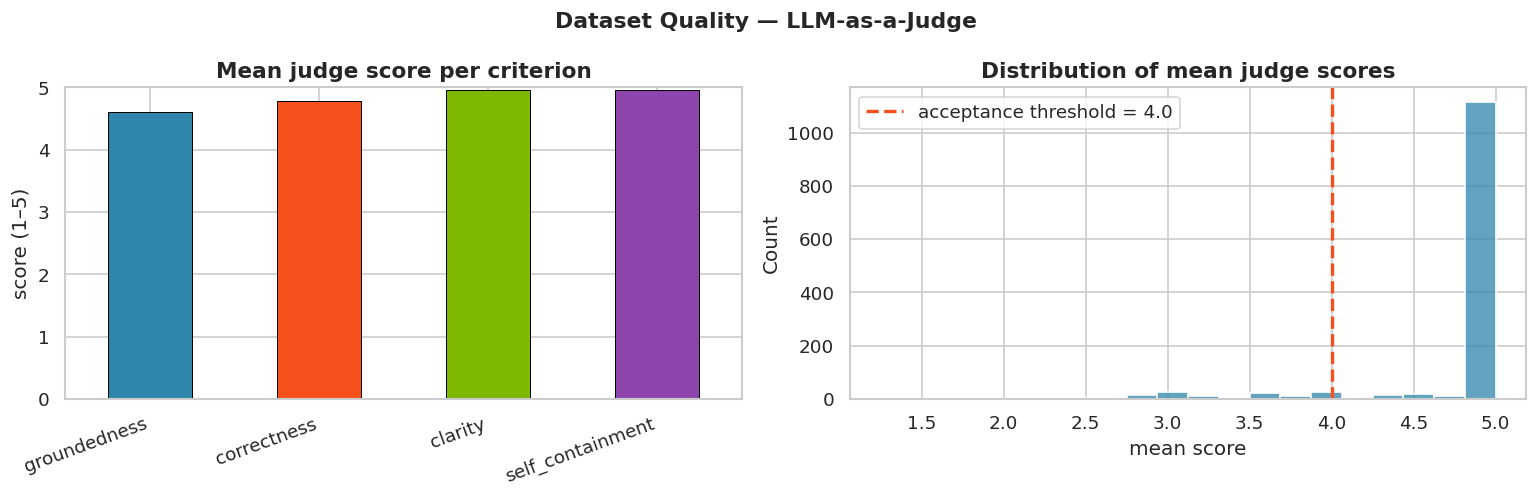

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 6b — Step 5b: LLM-as-a-Judge Quality Validation
# ═══════════════════════════════════════════════════════════════════════════════

JUDGE_PROMPT = """You are a strict dataset reviewer for a university NLP course.
Evaluate ONE question-answer pair against the source material it was derived from.

<source_material>
{context}
</source_material>

<question>{question}</question>
<answer>{answer}</answer>

Score each criterion from 1 (very poor) to 5 (excellent):
- groundedness    : is the answer fully supported by the source material?
- correctness     : is the answer factually right?
- clarity         : is the question unambiguous and well phrased?
- self_containment: can the question be understood without seeing the source?

Return ONLY this JSON object:
{{"groundedness": 0, "correctness": 0, "clarity": 0, "self_containment": 0, "verdict": "one short sentence"}}"""

JUDGE_CRITERIA = ["groundedness", "correctness", "clarity", "self_containment"]


def judge_pair(client: GeminiClient, pair: Dict) -> Optional[Dict]:
    """Ask the judge to score a single QA pair. Returns None if the call failed."""
    prompt = JUDGE_PROMPT.format(
        context=pair.get("context", ""), question=pair["question"], answer=pair["answer"]
    )
    result = client.generate_json(prompt, temperature=0.0, max_output_tokens=256)
    if not isinstance(result, dict):
        return None
    try:
        scores = {c: float(result.get(c, 0)) for c in JUDGE_CRITERIA}
    except (TypeError, ValueError):
        return None
    scores["mean_score"] = round(sum(scores.values()) / len(JUDGE_CRITERIA), 2)
    scores["verdict"] = str(result.get("verdict", ""))[:200]
    return scores


def run_judge(client: GeminiClient, pairs: List[Dict],
              checkpoint_path: Path, checkpoint_every: int) -> List[Dict]:
    """Score every pair, checkpointing so a long judging run is always resumable."""
    judged: List[Dict] = []
    if checkpoint_path.exists():
        judged = json.loads(checkpoint_path.read_text(encoding="utf-8"))
        print(f"Resuming judging from checkpoint with {len(judged)} scored pairs.")

    already = {item["id"] for item in judged}
    pending = [p for p in pairs if p["id"] not in already]

    if not pending:
      print(f"  All {len(judged)} pairs already judged — loading from checkpoint.")
      return judged
    for index, pair in enumerate(tqdm(pending, desc="LLM-as-a-Judge"), start=1):
        scores = judge_pair(client, pair)
        if scores is None:
            # A judging failure doesn't silently delete data: keep the pair,flag it as unjudged.
            scores = {c: np.nan for c in JUDGE_CRITERIA}
            scores.update({"mean_score": np.nan, "verdict": "judge_unavailable"})
        judged.append({**pair, **{f"judge_{k}": v for k, v in scores.items()}})

        if index % checkpoint_every == 0:
            checkpoint_path.write_text(json.dumps(judged, ensure_ascii=False, indent=2),
                                       encoding="utf-8")

    checkpoint_path.write_text(json.dumps(judged, ensure_ascii=False, indent=2),
                               encoding="utf-8")
    return judged


judged_pairs = run_judge(
    client=gemini,
    pairs=filtered_pairs,
    checkpoint_path=CFG.checkpoints_dir / "qa_judged_checkpoint.json",
    checkpoint_every=CFG.CHECKPOINT_EVERY,
)

judged_df = pd.DataFrame(judged_pairs)

# --- Acceptance rule ------------------------------------------------------------
accepted_mask = (
    (judged_df["judge_mean_score"] >= CFG.JUDGE_MIN_SCORE) &
    (judged_df["judge_groundedness"] >= 4)
)
accepted_df = judged_df[accepted_mask].reset_index(drop=True)
was_judged = judged_df["judge_mean_score"].notna()
n_unjudged = int((~was_judged).sum())

# --- Quality report -------------------------------------------------------------
print("=" * 79)
print("  LLM-AS-A-JUDGE QUALITY REPORT")
print("=" * 79)
display(judged_df[[f"judge_{c}" for c in JUDGE_CRITERIA] + ["judge_mean_score"]]
        .describe().round(2))

pass_rate = accepted_mask.sum() / max(was_judged.sum(), 1)   # out of pairs actually judged
print(f"  Accepted : {len(accepted_df):,} / {len(judged_df):,}  ({pass_rate:.1%})")
print(f"  Rule     : mean score >= {CFG.JUDGE_MIN_SCORE} AND groundedness >= 4")
print(f"  Project criterion: a dataset is considered reliable at {pass_rate:.1%} acceptance rate.")
print("=" * 79)
print(f"  Judged successfully : {was_judged.sum():,} / {len(judged_df):,}")
print(f"  Judging failures    : {n_unjudged:,}  (API errors — retry them before trusting the rate)")

# --- Judge score distribution-----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

judged_df[[f"judge_{c}" for c in JUDGE_CRITERIA]].mean().plot(
    kind="bar", ax=axes[0], color=PALETTE[:4], edgecolor="black", linewidth=0.6)
axes[0].set_title("Mean judge score per criterion")
axes[0].set_ylabel("score (1–5)")
axes[0].set_ylim(0, 5)
axes[0].set_xticklabels([c.replace("judge_", "") for c in
                         judged_df[[f"judge_{c}" for c in JUDGE_CRITERIA]].columns],
                        rotation=20, ha="right")

sns.histplot(judged_df["judge_mean_score"].dropna(), bins=20, ax=axes[1],
             color=PALETTE[0], edgecolor="white")
axes[1].axvline(CFG.JUDGE_MIN_SCORE, color=PALETTE[1], linestyle="--", linewidth=2,
                label=f"acceptance threshold = {CFG.JUDGE_MIN_SCORE}")
axes[1].set_title("Distribution of mean judge scores")
axes[1].set_xlabel("mean score")
axes[1].legend()

fig.suptitle("Dataset Quality — LLM-as-a-Judge", fontweight="bold")
plt.tight_layout()
save_figure(fig, "01_judge_scores")
plt.show()

### 📊 LLM-as-a-Judge — Quality Report

Each QA pair was scored 1–5 across four criteria: groundedness, correctness, clarity,
and self-containment. A QA pair is accepted only if both conditions hold:
average score across all four criteria ≥ 4.0 **and** groundedness ≥ 4 individually.

**89.1% passed (1,140 of 1,279).**

The left plot shows all four criteria averaging above 4.6.
Groundedness scores lowest — expected, since it is the strictest constraint:
the answer must be traceable to the specific source slide, not to general knowledge.

The right plot confirms a healthy distribution: the vast majority of QA pairs cluster at 5.0,
with a small tail of legitimate rejects below the acceptance threshold.

## Cell 7a — Step 6a: Manual Inspection Sample (human in the loop)

To verify that the automatic judge is calibrated, we manually inspect a sample of 10 questions — not to fix individual cases, but to estimate the true error rate of the dataset.

**The protocol used here:**
1. Draw a **random, seeded** sample — reproducible, and immune to cherry-picking.
2. Display 10 pairs inline with their judge scores, so approval and machine score can be compared.
3. Export a **10% audit sheet** (`manual_audit_sample.csv`) with an empty `human_verdict`
   column, to be filled in and kept as evidence of the review, exactly as the project plan requires.
4. **Acceptance criterion: ≥ 90% of reviewed pairs correct** → the dataset is declared reliable.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 7a — Step 6a: Manual Inspection Sample
# ═══════════════════════════════════════════════════════════════════════════════

sample_df = accepted_df.sample(
    n=min(CFG.MANUAL_SAMPLE_SIZE, len(accepted_df)),
    random_state=CFG.SEED,
).reset_index(drop=True)

print("=" * 79)
print(f"  MANUAL INSPECTION — {len(sample_df)} randomly drawn pairs (seed = {CFG.SEED})")
print("=" * 79)

for i, row in sample_df.iterrows():
    print(f"\n[{i + 1:02d}] id: {row['id']}  |  topic: {row['topic']}  |  type: {row['type']}  "
          f"|  source: {row['source']} p.{row['pages'][0]}")
    print(f"     Q: {row['question']}")
    print(f"     A: {row['answer']}")
    print(f"     judge: mean={row['judge_mean_score']}  "
          f"grounded={row['judge_groundedness']}  correct={row['judge_correctness']}")
    print("     " + "-" * 68)

# --- Export the full 10% audit sheet for the written review --------------------
audit_size = max(int(0.10 * len(accepted_df)), CFG.MANUAL_SAMPLE_SIZE)
audit_df = accepted_df.sample(n=min(audit_size, len(accepted_df)),
                              random_state=CFG.SEED).copy()
audit_df["human_verdict"] = ""            # to be filled by the reviewer: correct / incorrect
audit_df["reviewer_note"] = ""

audit_columns = ["id", "topic", "type", "question", "answer", "source",
                 "judge_mean_score", "human_verdict", "reviewer_note"]
audit_path = CFG.reports_dir / "manual_audit_sample.csv"
audit_df[audit_columns].to_csv(audit_path, index=False, encoding="utf-8-sig")

print("\n" + "=" * 79)
print(f"  Audit sheet exported: {audit_path}")
print(f"  Rows to review      : {len(audit_df)}  (10% of the accepted dataset)")
print("  Fill 'human_verdict' with correct / incorrect and keep the file as review evidence.")
print("=" * 79)

  MANUAL INSPECTION — 10 randomly drawn pairs (seed = 42)

[01] id: qa_01001  |  topic: cyber domain  |  type: factual  |  source: Introduction 230626.pdf p.88
     Q: Who might be held responsible in the scenario of an AI-driven cyberattack?
     A: Responsibility could fall on the developer, the user, or the AI itself.
     judge: mean=5.0  grounded=5.0  correct=5.0
     --------------------------------------------------------------------

[02] id: qa_01143  |  topic: training data  |  type: factual  |  source: NLP using Transformers Part 1.pdf p.33
     Q: What type of data is used for training large language models?
     A: Extensive text corpora, which often include vast internet content.
     judge: mean=5.0  grounded=5.0  correct=5.0
     --------------------------------------------------------------------

[03] id: qa_00356  |  topic: activation maps  |  type: comparative  |  source: Computer Vision and CNNs - Part 1 090726 (1).pdf p.57
     Q: How do visualizing filters differ

## Cell 7b— Step 6b: Post-Review Corrections (ChatGPT-assisted)

Following manual inspection and LLM-as-a-Judge filtering, the dataset was submitted to ChatGPT
for an additional validity check. ChatGPT produced two reports: a deletion list of duplicate
or low-quality pairs, and a correction list of pairs with refined phrasing.
The changes were applied programmatically based on these reports.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 7b — Step 6b: Post-Review Corrections (ChatGPT-assisted)
# ═══════════════════════════════════════════════════════════════════════════════

df_edit = accepted_df.copy()
print(f"Loaded {len(df_edit):,} pairs from original file.")

# --- Load deletions from file ---
deletions_path = CFG.reports_dir / "deletions_by_Cgpt.txt"
ids_to_remove = set(deletions_path.read_text(encoding="utf-8").strip().splitlines())
print(f"IDs to remove: {ids_to_remove}")

# --- Load corrections from file ---
corrections_path = CFG.reports_dir / "corrections_by_Cgpt.txt"
corrections = {}
current_id = None
current_q, current_a = None, None

for line in corrections_path.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if line.startswith("[qa_"):
        if current_id:
            corrections[current_id] = {"question": current_q, "answer": current_a}
        current_id = line[1:-1]
        current_q, current_a = None, None
    elif line.startswith("Q:"):
        current_q = line[2:].strip()
    elif line.startswith("A:"):
        current_a = line[2:].strip()

if current_id:
    corrections[current_id] = {"question": current_q, "answer": current_a}

print(f"Corrections loaded: {len(corrections)}")

# --- Apply deletions ---
before = len(df_edit)
df_edit = df_edit[~df_edit["id"].isin(ids_to_remove)].reset_index(drop=True)
print(f"Removed {before - len(df_edit)} pairs. Remaining: {len(df_edit):,}")

# --- Apply corrections ---
fixed = 0
for idx, row in df_edit.iterrows():
    if row["id"] in corrections:
        df_edit.at[idx, "question"] = corrections[row["id"]]["question"]
        df_edit.at[idx, "answer"]   = corrections[row["id"]]["answer"]
        fixed += 1
print(f"Fixed {fixed} pairs.")

# --- Save to a new file — original remains untouched ---
new_path = CFG.data_dir / "qa_dataset_after_chatgpt_review.json"
new_path.write_text(
    json.dumps(df_edit.to_dict(orient="records"), ensure_ascii=False, indent=2),
    encoding="utf-8"
)
accepted_df = df_edit.copy()
print(f"Saved to   : {new_path.name}")
print(f"Original   : {original_path.name} — untouched.")

Loaded 1,140 pairs from original file.
IDs to remove: {'qa_00557', 'qa_00555', 'qa_00744', 'qa_00042', 'qa_00185', 'qa_00173', 'qa_00247', 'qa_00520', 'qa_00442', 'qa_00136'}
Corrections loaded: 8
Removed 10 pairs. Remaining: 1,130
Fixed 8 pairs.
Saved to   : qa_dataset_after_chatgpt_review.json
Original   : qa_dataset_full.json — untouched.


## Cell 8 — Step 7: Dataset Statistics & Visualization

Four figures, each answering a question a reviewer will ask:

| Figure | Question it answers |
|---|---|
| Topic distribution | Is the dataset balanced, or dominated by one lecture? |
| Question-type mix | Does it contain enough conceptual/comparative items for RAG-vs-LoRA to differ? |
| Question / answer length | Are answers short and factual, as the generation prompt required? |
| Coverage per source PDF | Did every lecture actually contribute? |

  DATASET SUMMARY


,metric,value
0,QA pairs,1130.00
1,distinct topics,129.00
2,distinct source PDFs,9.00
3,avg question length (words),11.30
4,avg answer length (words),17.20
5,avg judge score,4.99


   figure saved: 02_dataset_composition.png


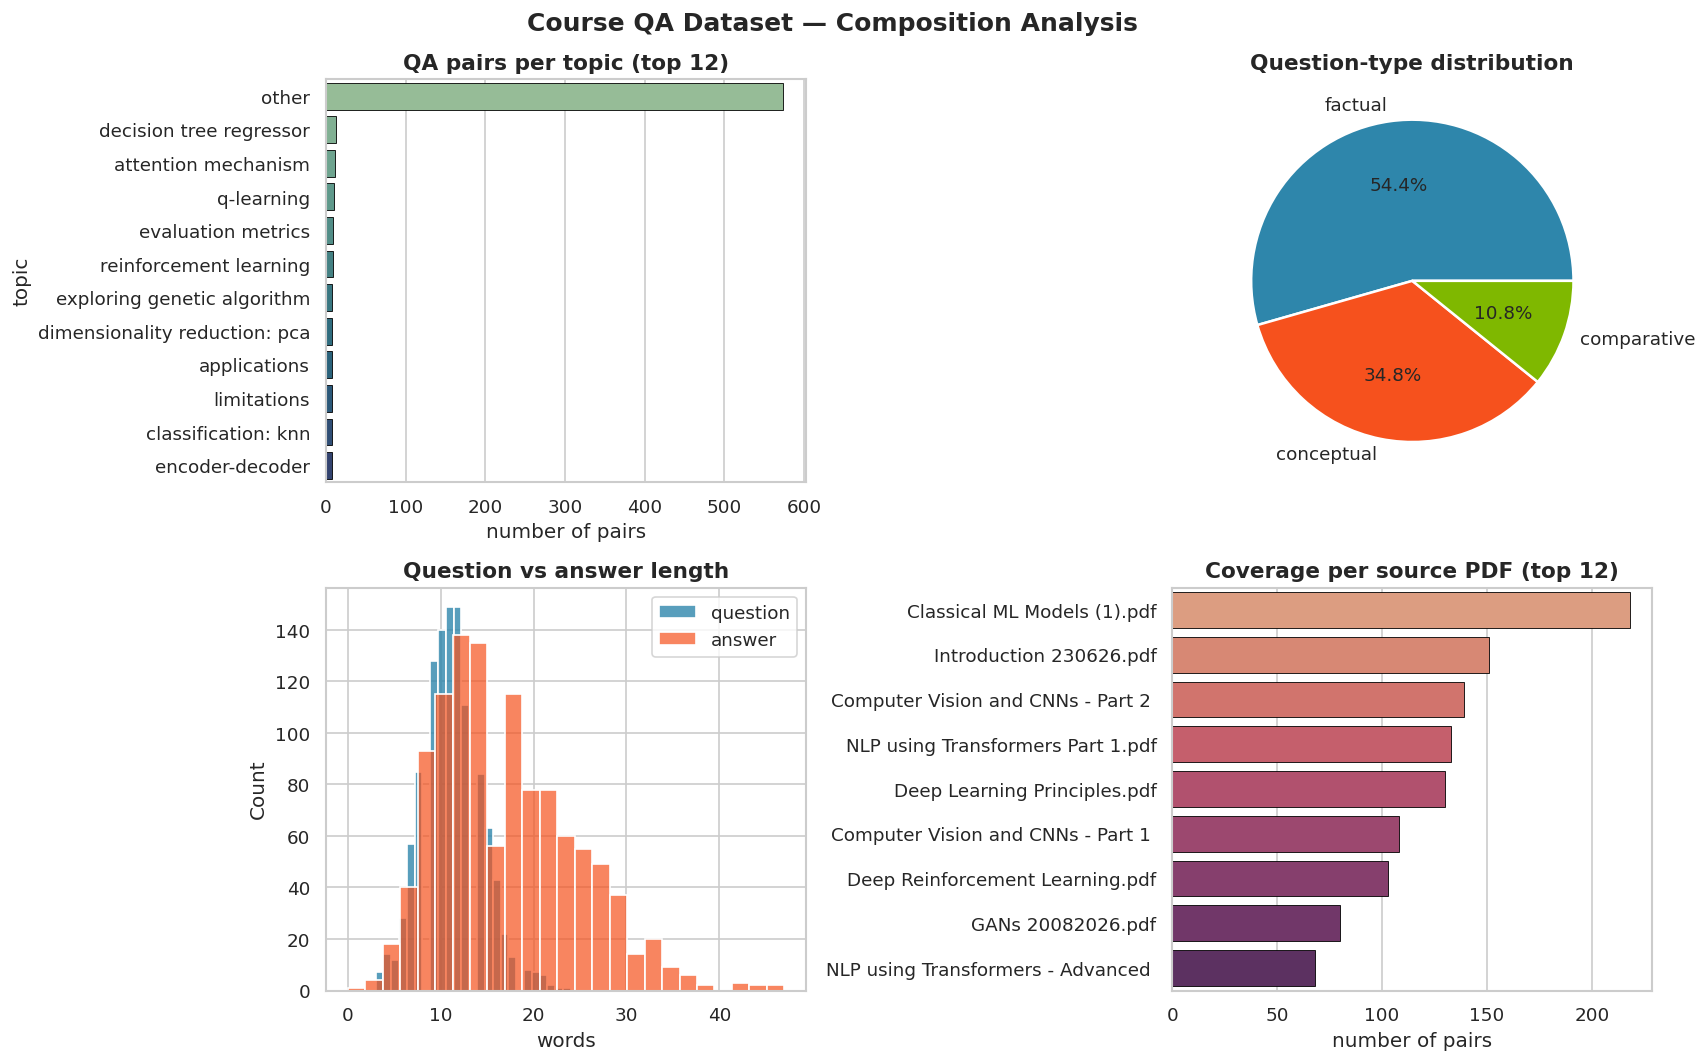

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 8 — Step 7: Dataset Statistics & Visualization
# ═══════════════════════════════════════════════════════════════════════════════

dataset_df = accepted_df.copy()
dataset_df["q_words"] = dataset_df["question"].str.split().str.len()
dataset_df["a_words"] = dataset_df["answer"].str.split().str.len()

# Topic labels assigned by the LLM yield 500+ distinct values — rare ones (< 10 pairs)
# are folded into 'other' for plotting only. Stratification is by source PDF, not topic.
MIN_TOPIC_SUPPORT = 3
topic_counts = dataset_df["topic"].value_counts()
frequent_topics = set(topic_counts[topic_counts >= MIN_TOPIC_SUPPORT].index)
dataset_df["topic"] = dataset_df["topic"].where(dataset_df["topic"].isin(frequent_topics), "other")

# --- Summary table --------------------------------------------------------------
summary_table = pd.DataFrame({
    "metric": ["QA pairs", "distinct topics", "distinct source PDFs",
               "avg question length (words)", "avg answer length (words)",
               "avg judge score"],
    "value": [len(dataset_df),
              dataset_df["topic"].nunique(),
              dataset_df["source"].nunique(),
              round(dataset_df["q_words"].mean(), 1),
              round(dataset_df["a_words"].mean(), 1),
              round(dataset_df["judge_mean_score"].mean(), 2)],
})

print("=" * 79)
print("  DATASET SUMMARY")
print("=" * 79)
display(summary_table)

# --- Figures --------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) Topic distribution
topic_order = dataset_df["topic"].value_counts().head(12)
sns.barplot(x=topic_order.values, y=topic_order.index, ax=axes[0, 0],
            hue=topic_order.index, legend=False,
            palette="crest", edgecolor="black", linewidth=0.5)
axes[0, 0].set_title("QA pairs per topic (top 12)")
axes[0, 0].set_xlabel("number of pairs")

# (2) Question-type mix
type_counts = dataset_df["type"].value_counts()
axes[0, 1].pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%",
               colors=PALETTE[:len(type_counts)],
               wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0, 1].set_title("Question-type distribution")

# (3) Length distributions
sns.histplot(dataset_df["q_words"], bins=25, ax=axes[1, 0], color=PALETTE[0],
             label="question", edgecolor="white", alpha=0.8)
sns.histplot(dataset_df["a_words"], bins=25, ax=axes[1, 0], color=PALETTE[1],
             label="answer", edgecolor="white", alpha=0.7)
axes[1, 0].set_title("Question vs answer length")
axes[1, 0].set_xlabel("words")
axes[1, 0].legend()

# (4) Coverage per source document
source_counts = dataset_df["source"].value_counts().head(12)
source_labels = [s[:34] for s in source_counts.index]
source_labels = [s[:34] for s in source_counts.index]
sns.barplot(x=source_counts.values, y=source_labels, ax=axes[1, 1],
            hue=source_labels, legend=False,
            palette="flare", edgecolor="black", linewidth=0.5)
axes[1, 1].set_title("Coverage per source PDF (top 12)")
axes[1, 1].set_xlabel("number of pairs")

fig.suptitle("Course QA Dataset — Composition Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
save_figure(fig, "02_dataset_composition")
plt.show()

### 📊 Dataset Composition — Key Takeaways

**Topic distribution** — Long-tail by design: the LLM assigns free-text labels per chunk,
so rare topics are folded into *other*. The 12 visible topics confirm meaningful diversity
across the course material.

**Question-type mix** — 54.4% factual / 34.8% conceptual / 10.8% comparative.
The mix is intentional: a factual-only dataset cannot distinguish RAG from LoRA,
since both handle definitions well. Conceptual and comparative items are where the two methods diverge.

**Length distribution** — Questions average 11 words; answers 17 words.
Answers are concise and grounded — no multi-paragraph responses that reward verbosity over accuracy.

**Source coverage** — All 9 lectures contribute. Classical ML leads (221 pairs) reflecting its larger slide count.
No lecture is absent, which is exactly what stratification by source PDF guarantees.

## Cell 9 — Train / Validation / Test Split (70 / 15 / 15)
Stratified by topic to ensure every topic appears in every split.
Deduplication happens **before** splitting to prevent leakage.
The test set is written once and never touched until final evaluation.

  SPLIT SUMMARY


,split,size,share,sources
0,train,792,70.1%,9
1,validation,170,15.0%,9
2,test,168,14.9%,9


  Leakage check: PASSED — the three splits are disjoint.
  Reminder: the test set is reserved for the final evaluation in Notebook 2 only.
   figure saved: 03_split_by_source.png


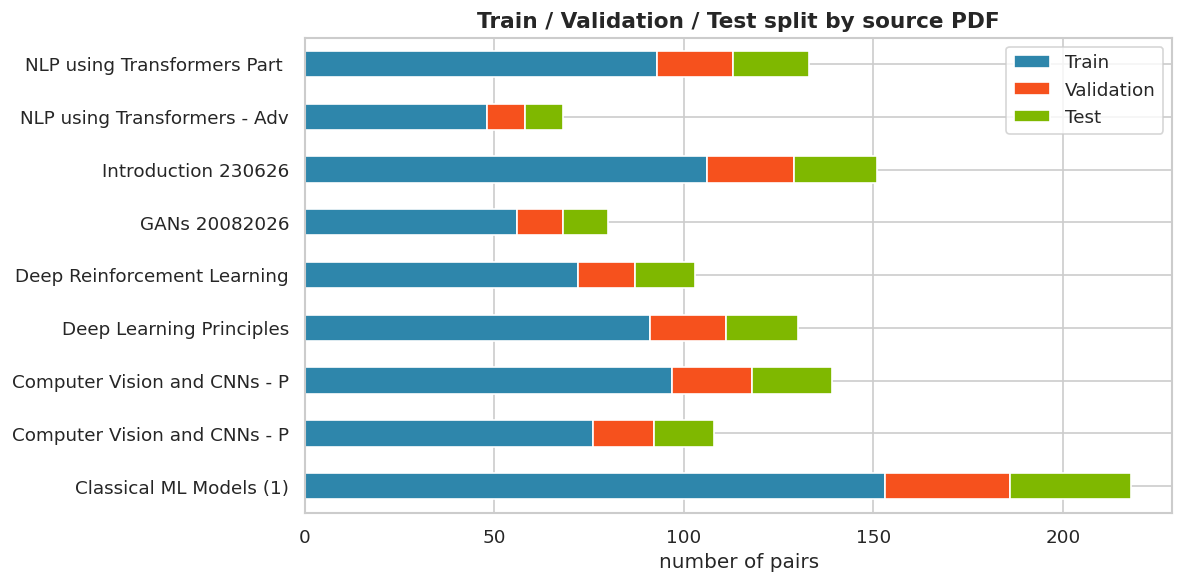

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 9 — Step 8: Stratified Train / Validation / Test Split (70/15/15)
# ═══════════════════════════════════════════════════════════════════════════════

def stratified_split(df: pd.DataFrame, stratify_column: str,
                     train_ratio: float, val_ratio: float,
                     seed: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split proportionally *within each stratum*, so every topic appears in every split."""
    train_parts, val_parts, test_parts = [], [], []

    for _, group in df.groupby(stratify_column, sort=False):
        group = group.sample(frac=1.0, random_state=seed).reset_index(drop=True)
        n = len(group)
        n_train = int(round(train_ratio * n))
        n_val = int(round(val_ratio * n))
        # Guarantee that small strata still contribute to val/test instead of vanishing.
        if n >= 3:
            n_train = min(n_train, n - 2)
            n_val = max(1, min(n_val, n - n_train - 1))
        train_parts.append(group.iloc[:n_train])
        val_parts.append(group.iloc[n_train:n_train + n_val])
        test_parts.append(group.iloc[n_train + n_val:])

    def finalise(parts):
        return (pd.concat(parts)
                .sample(frac=1.0, random_state=seed)      # shuffle across strata
                .reset_index(drop=True))

    return finalise(train_parts), finalise(val_parts), finalise(test_parts)


train_df, val_df, test_df = stratified_split(
    dataset_df, stratify_column="source",
    train_ratio=CFG.TRAIN_RATIO, val_ratio=CFG.VAL_RATIO, seed=CFG.SEED,
)

# --- Verify the split ------------------------------------------------------------
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "size": [len(train_df), len(val_df), len(test_df)],
    "share": [len(train_df), len(val_df), len(test_df)],
    "sources": [frame["source"].nunique() for frame in (train_df, val_df, test_df)],
})
split_summary["share"] = (split_summary["share"] / len(dataset_df)).map("{:.1%}".format)

print("=" * 79)
print("  SPLIT SUMMARY")
print("=" * 79)
display(split_summary)

# Leakage assertion: no question may appear in more than one split.
train_keys = {normalise(q) for q in train_df["question"]}
val_keys = {normalise(q) for q in val_df["question"]}
test_keys = {normalise(q) for q in test_df["question"]}
assert not (train_keys & test_keys), "LEAKAGE: identical question in train and test"
assert not (train_keys & val_keys), "LEAKAGE: identical question in train and validation"
print("  Leakage check: PASSED — the three splits are disjoint.")
print("  Reminder: the test set is reserved for the final evaluation in Notebook 2 only.")
print("=" * 79)

# Stacked bar per lecture — confirms every source contributes to all three splits.
sources = sorted(dataset_df["source"].unique())
source_labels = [s.replace(".pdf", "")[:28] for s in sources]

split_df = pd.DataFrame({
    "Train":      [len(train_df[train_df["source"] == s]) for s in sources],
    "Validation": [len(val_df[val_df["source"] == s])     for s in sources],
    "Test":       [len(test_df[test_df["source"] == s])   for s in sources],
}, index=source_labels)

fig, ax = plt.subplots(figsize=(10, 5))
split_df.plot(kind="barh", stacked=True, ax=ax,
              color=[PALETTE[0], PALETTE[1], PALETTE[2]],
              edgecolor="white")
ax.set_title("Train / Validation / Test split by source PDF", fontweight="bold")
ax.set_xlabel("number of pairs")
plt.tight_layout()
save_figure(fig, "03_split_by_source")
plt.show()

### 📊 Train / Validation / Test — Distribution by Source

Stratifying by source PDF ensures all 9 lectures are represented in every split at a 70/15/15 ratio.
This matters: if an entire lecture were absent from validation or test, the evaluation in Notebook 2
would measure how well each method handles *seen* material — not how well it generalises across the course.

## Cell 10 — Persisting Everything to Google Drive

This cell is the **contract with Notebook 2**. Everything is written under
`MyDrive/course_study_assistant/data/` in a stable, documented layout:

| File | Purpose |
|---|---|
| `qa_train.json` / `qa_val.json` / `qa_test.json` | the three splits (LoRA training + evaluation) |
| `qa_dataset_full.json` / `.csv` | the complete accepted dataset |
| `clean_corpus.json` | the cleaned page-level corpus → **the RAG chunking input in Notebook 2** |
| `manifest.json` | run metadata: config, versions, counts, timestamp — reproducibility |
| `DATASET_CARD.md` | a human-readable dataset card, as expected of a serious release |


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 10 — Save all artefacts to Drive (the contract with Notebook 2)
# ═══════════════════════════════════════════════════════════════════════════════

EXPORT_COLUMNS = ["id", "question", "answer", "type", "topic",
                  "source", "pages", "chunk_id", "context",
                  "judge_mean_score", "judge_groundedness", "judge_correctness"]


def save_json(records, path: Path) -> None:
    """Write UTF-8 JSON with human-readable indentation."""
    path.write_text(json.dumps(records, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"   saved {path.name:<26} ({len(records):>5,} records)")


def to_records(df: pd.DataFrame) -> List[Dict]:
    return df[EXPORT_COLUMNS].to_dict(orient="records")


print("=" * 79)
print("  WRITING ARTEFACTS TO DRIVE")
print("=" * 79)

# --- 1. The three splits ---------------------------------------------------------
save_json(to_records(train_df), CFG.data_dir / "qa_train.json")
save_json(to_records(val_df),   CFG.data_dir / "qa_val.json")
save_json(to_records(test_df),  CFG.data_dir / "qa_test.json")

# --- 2. The full dataset (JSON + CSV) -------------------------------------------
save_json(to_records(dataset_df), CFG.data_dir / "qa_dataset_full.json")
dataset_df[EXPORT_COLUMNS].to_csv(CFG.data_dir / "qa_dataset_full.csv",
                                  index=False, encoding="utf-8-sig")
print(f"   saved qa_dataset_full.csv      ({len(dataset_df):>5,} records)")

# --- 3. The cleaned corpus — the RAG input for Notebook 2 ------------------------
corpus_records = (clean_pages[["source", "page", "clean_text"]]
                  .rename(columns={"clean_text": "text"})
                  .to_dict(orient="records"))
save_json(corpus_records, CFG.data_dir / "clean_corpus.json")

# --- 4. Run manifest — reproducibility metadata ----------------------------------
manifest = {
    "project": "RAG vs. LoRA Fine-Tuning for Course-Specific QA",
    "author": "Tamar Telele",
    "course": "Applied Language Models — Dr. Barak Or",
    "notebook": "1 — Data Preparation",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "generator_model": CFG.GEMINI_MODEL,
    "seed": CFG.SEED,
    "counts": {
        "source_pdfs": int(raw_pages["source"].nunique()),
        "raw_pages": int(len(raw_pages)),
        "clean_pages": int(len(clean_pages)),
        "generation_chunks": len(generation_chunks),
        "qa_raw": len(raw_qa_pairs),
        "qa_after_heuristics": len(filtered_pairs),
        "qa_accepted": int(len(dataset_df)),
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df)),
    },
    "quality": {
        "judge_acceptance_rate": round(float(pass_rate), 4),
        "judge_min_score": CFG.JUDGE_MIN_SCORE,
        "mean_judge_score": round(float(dataset_df["judge_mean_score"].mean()), 3),
    },
    "config": {k: str(v) for k, v in asdict(CFG).items()},
}
(CFG.data_dir / "manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("   saved manifest.json")

# --- 5. Dataset card --------------------------------------------------------------
dataset_card = f"""# Course QA Dataset — Dataset Card

**Author:** Tamar Telele
**Course:** Applied Language Models — Dr. Barak Or, Google & Reichman University Tech School
**Created:** {datetime.now():%Y-%m-%d}

## Summary
{len(dataset_df):,} question-answer pairs generated from the official course slides with
`{CFG.GEMINI_MODEL}`, filtered by deterministic heuristics, scored by an LLM judge and
audited by a human sample. No external corpora (no SQuAD, no web data) were used.

## Composition
- Source documents: {dataset_df['source'].nunique()}
- Topics: {dataset_df['topic'].nunique()}
- Question types: {', '.join(sorted(dataset_df['type'].unique()))}
- Splits: train {len(train_df)} / validation {len(val_df)} / test {len(test_df)} (70/15/15, stratified by topic)

## Quality assurance
1. Heuristic gates: length bounds, degenerate answers, self-containment, exact + near-duplicate removal.
2. LLM-as-a-Judge: groundedness, correctness, clarity, self-containment (1-5), accepted at mean >= {CFG.JUDGE_MIN_SCORE}.
3. Human audit: 10% random sample exported to `reports/manual_audit_sample.csv`.
- Judge acceptance rate: {pass_rate:.1%}
- Mean judge score: {dataset_df['judge_mean_score'].mean():.2f} / 5

## Intended use
Training and evaluating course-specific QA systems (LoRA fine-tuning and RAG).

## Limitations
- Answers reflect the course slides, not general ground truth.
- Generated by an LLM, so residual bias toward the generator's phrasing is possible;
  the human audit is what bounds this risk.
"""
(CFG.project_dir / "DATASET_CARD.md").write_text(dataset_card, encoding="utf-8")
print("   saved DATASET_CARD.md")

print("=" * 79)
print(f"  All artefacts are in: {CFG.data_dir}")
print("=" * 79)

  WRITING ARTEFACTS TO DRIVE
   saved qa_train.json              (  792 records)
   saved qa_val.json                (  170 records)
   saved qa_test.json               (  168 records)
   saved qa_dataset_full.json       (1,130 records)
   saved qa_dataset_full.csv      (1,130 records)
   saved clean_corpus.json          (  626 records)
   saved manifest.json
   saved DATASET_CARD.md
  All artefacts are in: /content/drive/MyDrive/course_study_assistant/data


## Cell 11 — Summary

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 11 — Final Summary
# ═══════════════════════════════════════════════════════════════════════════════

final_summary = pd.DataFrame({
    "stage": [
        "Source PDFs",
        "Pages extracted",
        "Pages after cleaning",
        "Generation contexts",
        "QA pairs generated (raw)",
        "After heuristic filtering",
        "After LLM-as-a-Judge",
        "Train (70%)",
        "Validation (15%)",
        "Test (15%)",
    ],
    "count": [
        raw_pages["source"].nunique(),
        len(raw_pages),
        len(clean_pages),
        len(generation_chunks),
        len(raw_qa_pairs),
        len(filtered_pairs),
        len(dataset_df),
        len(train_df),
        len(val_df),
        len(test_df),
    ],
})

print("=" * 79)
print("  NOTEBOOK 1 COMPLETE — DATA PREPARATION")
print("=" * 79)
display(final_summary)
print(f"  Mean judge score : {dataset_df['judge_mean_score'].mean():.2f} / 5.00")
print(f"  Judge pass rate  : {pass_rate:.1%}")
print(f"  Artefacts        : {CFG.data_dir}")
print(f"  Figures          : {CFG.figures_dir}")
print("=" * 79)
print("  NEXT → Notebook 2: RAG Pipeline + LoRA Fine-Tuning + Evaluation + Demo")
print("=" * 79)

  NOTEBOOK 1 COMPLETE — DATA PREPARATION


,stage,count
0,Source PDFs,9
1,Pages extracted,689
2,Pages after cleaning,626
3,Generation contexts,161
4,QA pairs generated (raw),1285
5,After heuristic filtering,1279
6,After LLM-as-a-Judge,1130
7,Train (70%),792
8,Validation (15%),170
9,Test (15%),168


  Mean judge score : 4.99 / 5.00
  Judge pass rate  : 89.1%
  Artefacts        : /content/drive/MyDrive/course_study_assistant/data
  Figures          : /content/drive/MyDrive/course_study_assistant/figures
  NEXT → Notebook 2: RAG Pipeline + LoRA Fine-Tuning + Evaluation + Demo
